In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import random

from PIL import Image
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.utils.data as data
import torchvision
import torchvision.transforms as T

import math
import cv2
from pathlib import Path

In [24]:
class ImageDataset(data.Dataset):

    def __init__(self, root, new_size=592, supervised = True):

        self.root = Path(root)
        self.supervised = supervised

        self.image_paths = sorted(self.root.rglob('*.tif')) + sorted(self.root.rglob('*.tiff'))
        self.image_liot_eg_paths = sorted(self.root.rglob('*_liot_eg*.npy'))
        if self.supervised:
            self.label_paths = sorted(self.root.rglob('*_mask.png')) + sorted(self.root.rglob('*_mask.gif'))

        if len(self.image_paths) != len(self.image_liot_eg_paths):
            raise ValueError(f"Dataset mismatch: {len(self.image_paths)} images vs {len(self.image_liot_eg_paths)} LIOT examples in {self.root}")
        if self.supervised and len(self.image_paths) != len(self.label_paths):
            raise ValueError(f"Dataset mismatch: {len(self.image_paths)} images vs {len(self.label_paths)} labels in {self.root}")

        self.new_size = new_size
        self.imagesize = None

    def borders(self, original_size):
        """
        Compute padding for target size
        """
        H, W = original_size
        delta_h = max(self.new_size - H, 0)
        delta_w = max(self.new_size - W, 0)

        top    = delta_h // 2
        bottom = delta_h - top
        left   = delta_w // 2
        right  = delta_w - left

        return left, top, right, bottom

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        image = Image.open(image_path)
        image_liot_eg_path = self.image_liot_eg_paths[index]
        image_liot_eg = np.load(image_liot_eg_path)

        if self.supervised:
            label_path = self.label_paths[index]
            label = Image.open(label_path)

        self.imagesize = np.shape(image)[0:2]

        transform = []
        transform.append(T.ToTensor())
        transform.append(T.Pad(
            self.borders(self.imagesize))
        )
        transform = T.Compose(transform)
        image = transform(image)
        image_liot_eg = transform(image_liot_eg.transpose(1, 2, 0))

        if self.supervised:

            label = transform(label)
            return image, image_liot_eg, label

        return image, image_liot_eg

    def __len__(self):
        return len(self.image_paths)


Dataset:  {'train supervised': 20, 'test': 20}
original size:  (584, 565)


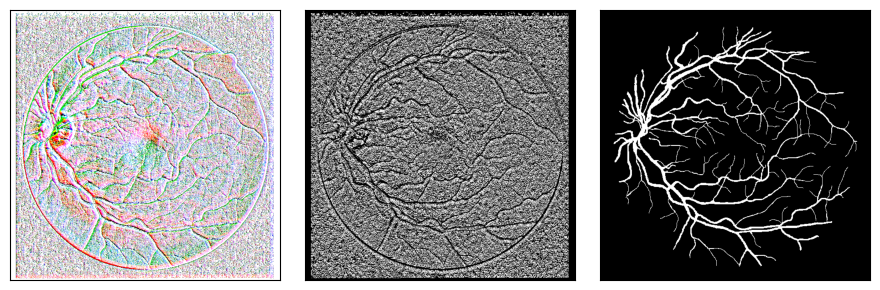

In [25]:
root = r"E:\work\pfe_work\code\Hessian-based Deep Retinal Vessel Segmentation with Extremely Few Annotations\prepared data"
test_dataset = ImageDataset(root = os.path.join(root,'test_data'))
train_dataset_supervised = ImageDataset(root = os.path.join(root,'train_data_s'))

train_dataloader_supervised = data.DataLoader(train_dataset_supervised, shuffle = True, batch_size= 2)
test_dataloader = data.DataLoader(test_dataset, shuffle = False, batch_size = 1)

dataloaders = {'train supervised' : train_dataloader_supervised,  'test' : test_dataloader}
dataset_sizes = {'train supervised' : train_dataset_supervised.__len__(),'test' : test_dataset.__len__()}
batch_sizes =  {'train supervised' : 2, 'test' : 1}
print("Dataset: ", dataset_sizes)
it = iter(dataloaders['test'])
inputs, inputs_LIOT_eg, labels = next(it)
print("original size: ", test_dataset.imagesize)
original_size = T.CenterCrop(test_dataset.imagesize)
out_inputs = torchvision.utils.make_grid(inputs)
out_LIOT_eg_inputs = torchvision.utils.make_grid(inputs_LIOT_eg)
out_labels = torchvision.utils.make_grid(labels)

fig,axes = plt.subplots(1,3,figsize=(9,3))
axes[0].imshow(out_inputs.permute(1,2,0))
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].imshow(out_LIOT_eg_inputs[0], cmap = "gray")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[2].imshow(out_labels.permute(1,2,0))
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.tight_layout()
plt.show()

In [26]:
class DoubleConv(nn.Module):
    '''
    Apply two 3×3 convolutions (padding=1), batch normalization and ReLU.
    '''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.doubleconv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.doubleconv(x)

class Down(nn.Module):
    '''
    Apply 2×2 max pooling, then double convolution.
    '''
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.downconv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.downconv(x)

class Up(nn.Module):
    '''
    Apply a transposed convolution for upsampling, then double convolution.
    '''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):

    def __init__(self, in_channels):
        super().__init__()
        self.inc = DoubleConv(in_channels,64)
        self.down1 = Down(64,128)
        self.down2 = Down(128,256)
        self.down3 = Down(256,512)
        self.down4 = Down(512,1024)
        self.up1 = Up(1024,512)
        self.up2 = Up(512,256)
        self.up3 = Up(256,128)
        self.up4 = Up(128,64)
        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.out(x)
        return x

In [27]:
def clahe(inputs, clipLimit=4, tileGridSize=(8,8)):
    """
    Compute CLAHE for green channel of inputs.
    """
    inputs = inputs.to('cpu')
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    green_channel = np.uint8(255 * inputs[:,1,:,:])
    res = np.array([clahe.apply(i) for i in green_channel], dtype=float) / 255
    res = torch.tensor(res, dtype=torch.float).unsqueeze(1)
    return res.to(device)

In [28]:
class BZ_Loss(nn.Module):

    def __init__(self, config_loss = 0, config_bz = 0):

        super(BZ_Loss, self).__init__()
        self.Gx = torch.tensor(([-1,0,1],[-2,0,2],[-1,0,1]), dtype = torch.float)
        self.Gy = torch.tensor(([1,2,1],[0,0,0],[-1,-2,-1]), dtype = torch.float)
        self.RGB_to_GRAY = T.Grayscale()
        self.config_loss = config_loss
        self.config_bz = config_bz

    def gaussian_kernel(self, kernel_size, sigma):
        """
        Return a gaussian kernel.
        """
        ax = torch.linspace(-(kernel_size - 1) / 2., (kernel_size - 1) / 2., kernel_size)
        xx, yy = torch.meshgrid(ax, ax, indexing = 'xy')
        kernel = torch.exp( -0.5 * (torch.square(xx) + torch.square(yy))/ sigma ** 2)
        kernel =  kernel / torch.sum(kernel)
        return kernel.unsqueeze(0).unsqueeze(0).to(device)

    def gaussian_filter(self, inputs, kernel_size, sigma):
        """
        Apply a gaussian kernel to inputs.
        """
        return F.conv2d(inputs, weight = self.gaussian_kernel(kernel_size, sigma), padding = kernel_size//2)

    def hessian_square_norm(self, inputs, kernel_size = 5, sigma = 1):
        """
        Compute the squared norm of the positive, non-mixed second-order partial derivatives.
        """
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxxy = torch.stack((self.Gx, self.Gx, self.Gy))
        Gxxy = Gxxy.unsqueeze(1).to(device)
        Gxyy = torch.stack((self.Gx,self.Gy,self.Gy))
        Gxyy = Gxyy.unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight =  Gxxy, padding = 1, groups = 1)
        x = F.conv2d(x, weight = Gxyy, padding = 1, groups = 3)
        x = torch.square(x *(x>0))
        x[:,1,:,:] = 0 * x[:,1,:,:]
        x = torch.sum(x, dim = 1, keepdim = True)
        return x

    def hessian_square_norm_binarized(self, inputs, kernel_size = 5, sigma = 1):
        """
        Binarize the hessian_square_norm function.
        """
        x = self.hessian_square_norm(inputs)
        x = (x-torch.min(x))/(torch.max(x)-torch.min(x))
        t = 1e-2
        x = torch.where((x > t), 1, 0)
        # x = remove_circle(inputs, x, 5, 0.1)
        return x.float()

    def hessian_supervised_denoised_BZ(self, inputs, labels, kernel_size = 5, sigma = 1):
        """
        Compute a supervised version of the hessian_square_norm function.
        """
        denoised_labels = self.gaussian_filter(labels, kernel_size, sigma)
        hessian_norm = self.hessian_square_norm(inputs)
        x = torch.mul(denoised_labels, hessian_norm)

        return x.float()

    def gradient_square_norm(self, inputs, kernel_size = 1, sigma = 1):
        """
        Compute the squared norm of the gradient.
        """
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxy = torch.stack((self.Gx, self.Gy))
        Gxy = Gxy.unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight =  Gxy, padding = 1, groups = 1)
        x = torch.square(x)
        x = torch.sum(x, dim = 1, keepdim = True)
        return x

    def forward(self, outputs, labels, inputs, alpha ,eps, beta, k_eps, supervised):

        match self.config_bz:
            case 0:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_square_norm(inputs))
            case 1:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_supervised_denoised_BZ(inputs, labels))

        BZ2 = beta * (torch.sum( (eps * self.gradient_square_norm(1-outputs) + torch.square(outputs)/(4 * eps))))
        BZ = BZ1 + BZ2
        BCE = nn.BCELoss()

        match self.config_loss:
            case 0:
                loss = alpha * BZ + BCE(outputs, labels)
            case 1:
                loss = alpha * BZ + 0.5*BCE(outputs, labels) + 0.5*BCE(outputs, self.hessian_square_norm_binarized(inputs))

        return loss

In [29]:
def accuracy(preds, labels, eps=1e-6):

    preds = original_size(preds)
    labels = original_size(labels)
    corr = float(torch.sum(preds==labels))
    tensor_size = float(labels.size(0)*labels.size(1)*labels.size(2)*labels.size(3))

    return corr/(tensor_size+eps)

def sensitivity(preds, labels, eps=1e-6):

    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))

    return TP/(TP+FN+eps)

def specificity(preds, labels, eps=1e-6):

    preds = original_size(preds)
    labels = original_size(labels)
    TN = float(torch.sum((preds == 0)*(labels == 0)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))

    return TN/(TN+FP+eps)

def precision(preds, labels, eps=1e-6):

    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))

    return TP/(TP+FP+eps)

def dice_coef(preds, labels, eps=1e-6):

    preds = original_size(preds)
    labels = original_size(labels)

    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))

    return 2*TP/(2*TP+FP+FN+eps)

In [30]:
def remove_circle(inputs, preds, kernel_size, threshold):
    """
    Mask of the inside of the eye.
    """
    RGB_to_GRAY = T.Grayscale()
    mask = 1.*(RGB_to_GRAY(inputs)> threshold)

    p1 = -F.max_pool2d(-1.*mask,kernel_size =  (kernel_size,1), stride = (1,1),
                       padding = (kernel_size//2,0))
    p2 = -F.max_pool2d(-1.*mask,kernel_size =  (1,kernel_size), stride = (1,1),
                       padding = (0,kernel_size//2))

    mask = torch.min(p1,p2)
    return preds * mask

In [31]:
def train_model(model, criterion, optimizer, num_epochs):

    since = time.time()

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-' * 30)

        for inputs, inputs_LIOT_vp, labels in dataloaders['train supervised']:

            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs_LIOT_vp)
            outputs = F.sigmoid(outputs)

            loss = criterion(outputs,
                             labels,
                             clahe(inputs),
                             alpha = 0.7/(inputs.shape[-1]**2),
                             eps = 0.1,
                             beta = 0.5,
                             k_eps = 0,
                             supervised = True)

            loss.backward()
            optimizer.step()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))

    return model

In [32]:
def train_model_enhancing(model, model_enhancing, criterion, optimizer, num_epochs):

    since = time.time()

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-' * 30)

        for inputs, inputs_LIOT_vp, labels in dataloaders['train supervised']:

            optimizer.zero_grad()

            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            outputs = model(inputs_LIOT_vp)
            outputs = F.sigmoid(outputs)

            outputs_enhancing = model_enhancing(outputs)
            outputs_enhancing = F.sigmoid(outputs_enhancing)

            loss = criterion(outputs_enhancing, labels)

            loss.backward()
            optimizer.step()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))

    return model_enhancing

In [33]:
def test_model_enhancing(model, model_enhancing, threshold_enhancing, BZ, display_results = False):

    with torch.no_grad():
        model.eval()
        model_enhancing.eval()
        acc, sn, sp, pcs, dc, cldc = 0, 0, 0, 0, 0, 0
        lacc, lsn, lsp, lpcs, ldc, lcldc = [],[],[],[],[],[]
        count_img = 0
        for inputs, inputs_LIOT_vp, labels in dataloaders['test']:

            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            outputs = model(inputs_LIOT_vp)
            outputs = F.sigmoid(outputs)

            outputs_enhancing = model_enhancing(outputs)

            outputs_enhancing = F.sigmoid(outputs_enhancing)
            preds_enhancing = outputs_enhancing > threshold_enhancing

            if BZ:
                preds_enhancing = remove_circle(inputs, preds_enhancing, 7, 0.1)

            acc += accuracy(preds_enhancing,labels)
            sn += sensitivity(preds_enhancing,labels)
            sp += specificity(preds_enhancing,labels)
            pcs += precision(preds_enhancing,labels)
            dc += dice_coef(preds_enhancing,labels)

            lacc.append(accuracy(preds_enhancing,labels))
            lsn.append(sensitivity(preds_enhancing,labels))
            lsp.append(specificity(preds_enhancing,labels))
            lpcs.append(precision(preds_enhancing,labels))
            ldc.append(dice_coef(preds_enhancing,labels))

            if display_results:
                grid = torchvision.utils.make_grid([labels[0],preds_enhancing[0]]).cpu()
                plt.figure(figsize=(8, 8))
                plt.imshow(grid.permute(1,2,0))
                plt.xticks([])
                plt.yticks([])

        acc = acc / dataset_sizes['test']
        sn = sn / dataset_sizes['test']
        sp = sp / dataset_sizes['test']
        pcs = pcs / dataset_sizes['test']
        dc = dc / dataset_sizes['test']

        print('Acc: {:.2f} Sn: {:.2f} Sp: {:.2f} Pcs: {:.2f} DC: {:.2f}'.format(
                    100*acc, 100*sn, 100*sp, 100*pcs, 100*dc))

        return dc

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
UNet1 = UNet(10)
UNet1.to(device)
UNet1.train()
class_criterion = BZ_Loss(config_loss = 0, config_bz = 0)
optimizer = optim.Adam(UNet1.parameters(), lr=1e-3, betas=(0.9,0.999), eps=1e-07)
UNet1 = train_model(UNet1, class_criterion, optimizer, num_epochs = 150)

UNet1_enhancing = UNet(1)
UNet1_enhancing.to(device)
UNet1_enhancing.train()
class_criterion = nn.BCELoss()
optimizer = optim.Adam(UNet1_enhancing.parameters(), lr=1e-3, betas=(0.9,0.999), eps=1e-07)
UNet1_enhancing = train_model_enhancing(UNet1, UNet1_enhancing, class_criterion, optimizer, 150)

In [ ]:
#Thresholds can shift between runs; use a small validation set to pick the best one.
for i in [0.1, 0.2, 0.3, 0.4, 0.5]:
    th = i
    test_model_enhancing(UNet1, UNet1_enhancing, th, BZ = True, display_results = True)